In [ ]:
from PIL import Image
image=Image.open('/content/nature.jpg')

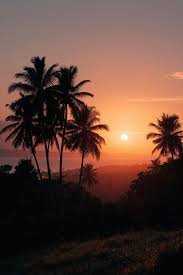

In [ ]:
image_resized=image.resize((300,300))
image

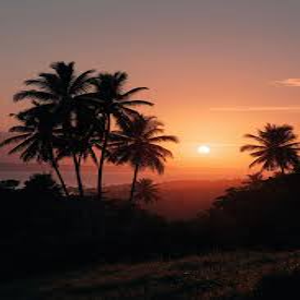

In [ ]:
image_resized

In [ ]:
import numpy as np
image_array=np.array(image)/255.0 #for normalization /255.0
image_array

array([[[0.45098039, 0.43529412, 0.43921569],
        [0.45098039, 0.43529412, 0.43921569],
        [0.45098039, 0.43529412, 0.43921569],
        ...,
        [0.48235294, 0.44313725, 0.43921569],
        [0.48235294, 0.44313725, 0.43921569],
        [0.48235294, 0.44313725, 0.43921569]],

       [[0.45098039, 0.43529412, 0.43921569],
        [0.45098039, 0.43529412, 0.43921569],
        [0.45098039, 0.43529412, 0.43921569],
        ...,
        [0.48235294, 0.44313725, 0.43921569],
        [0.48235294, 0.44313725, 0.43921569],
        [0.48235294, 0.44313725, 0.43921569]],

       [[0.45490196, 0.43921569, 0.44313725],
        [0.45490196, 0.43921569, 0.44313725],
        [0.45490196, 0.43921569, 0.44313725],
        ...,
        [0.48235294, 0.44313725, 0.43921569],
        [0.48235294, 0.44313725, 0.43921569],
        [0.48235294, 0.44313725, 0.43921569]],

       ...,

       [[0.02745098, 0.04313725, 0.04705882],
        [0.02745098, 0.04313725, 0.04705882],
        [0.02745098, 0

array([[112, 112, 112, ..., 114, 114, 114],
       [112, 112, 112, ..., 114, 114, 114],
       [113, 113, 113, ..., 114, 114, 114],
       ...,
       [ 11,  11,  11, ...,   5,   5,   5],
       [ 11,  11,  11, ...,   5,   5,   5],
       [ 11,  11,  11, ...,   5,   5,   5]], dtype=uint8)
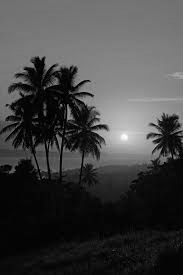

In [ ]:
# convert into grayscale
from cv2 import cvtColor,COLOR_BGR2GRAY
image_np=np.array(image)
grayscale_image=cvtColor(image_np,COLOR_BGR2GRAY)
grayscale_image

DATA AUGMENTATION

In [ ]:
from PIL import Image,ImageEnhance,ImageOps
import os

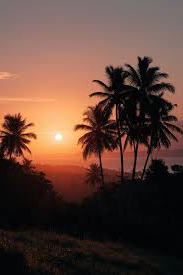

In [ ]:
# flips the image horizontally(mirrorimng)
flipped=ImageOps.mirror(image)
flipped

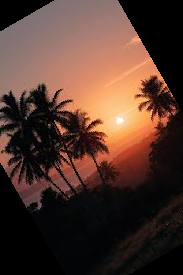

In [ ]:
#rotate
rotated=image.rotate(30) #rotates the image by 30 degrees
rotated

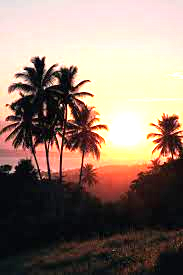

In [ ]:
# brightness adjustment
enhancer=ImageEnhance.Brightness(image)
#adjusts brightness by a factor of 2.0
brighter=enhancer.enhance(2.0)
brighter

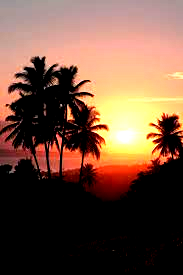

In [ ]:
# contrast adjustment
contrast=ImageEnhance.Contrast(image).enhance(2.0)
#doubles the image's contrast(2.0=twice the original)
contrast

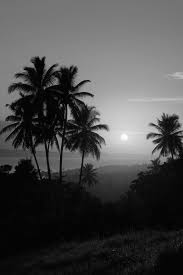

In [ ]:
#grayscale
grayscale=ImageOps.grayscale(image)
grayscale

In [ ]:
from PIL import Image, ImageEnhance, ImageOps
#PIL: Python Imaging Library (via Pillow), used for image processing.
#Image: Handles image loading, saving, and manipulation.
#ImageEnhance: Provides tools for enhancing image properties like brightness and contrast.
#ImageOps: Contains image processing utilities, such as flipping and grayscaling.
#os: A module to handle file system operations like creating directories and file paths.

import os

# Load the uploaded image
image_path = "/content/nature.jpg"  # Replace with your image file path
image = Image.open(image_path)

# Create a directory for augmented images
augmented_dir = "augmented_images"
#Creates the directory augmented_images
os.makedirs(augmented_dir, exist_ok=True)
 #Ensures no error is raised if the directory already exists.

# Augmentation functions
def augment_image(image, output_dir):
    # 1. Horizontal Flip
    # Flips the image horizontally (mirroring).
    flipped = ImageOps.mirror(image)
    #Saves the flipped image as flipped.jpeg in the output_dir
    flipped.save(os.path.join(output_dir, "flipped.jpeg"))

    # 2. Rotate
    rotated = image.rotate(30)
    #Rotates the image by 30 degrees (counterclockwise by default)
    rotated.save(os.path.join(output_dir, "rotated.jpeg"))

    # 3. Brightness Adjustment
    enhancer = ImageEnhance.Brightness(image)
    #Adjusts brightness by a factor of 1.5 (1.0 = original brightness).
    brighter = enhancer.enhance(1.5)
    brighter.save(os.path.join(output_dir, "brighter.jpeg"))

    # 4. Contrast Adjustment
    contrast = ImageEnhance.Contrast(image).enhance(2.0)
    #Doubles the image's contrast (2.0 = twice the original contrast).

    contrast.save(os.path.join(output_dir, "contrast.jpeg"))

    # 5. Grayscale
    grayscale = ImageOps.grayscale(image)
    grayscale.save(os.path.join(output_dir, "grayscale.jpeg"))

# Apply augmentations
augment_image(image, augmented_dir)
#Calls the augment_image function to apply all augmentations on the loaded image and save the results in the augmented_images directory.

# List the augmented files
print("Augmented images saved in:", augmented_dir)
print("Generated files:", os.listdir(augmented_dir))

Augmented images saved in: augmented_images
Generated files: ['rotated.jpeg', 'brighter.jpeg', 'flipped.jpeg', 'grayscale.jpeg', 'contrast.jpeg']


In [ ]:
import matplotlib.pyplot as plt
# used to open and m,anipulate images

In [ ]:
#list all augmented image files
augmented_images=os.listdir(augmented_dir)
#plot each augmented image
plt.figure(figsize=(12,8)) #adjust the size of the plot

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

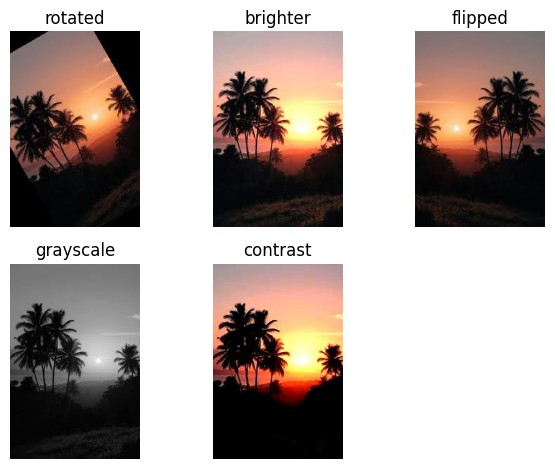

In [ ]:
for i,img_file in enumerate(augmented_images):
  #open each image
  img_path=os.path.join(augmented_dir,img_file)
  #combines the directory path and the image file name
  img=Image.open(img_path)# display the image
  plt.subplot(2,3,i+1)
  #adjust layout(2 rows,3 columns)
  plt.imshow(img,cmap='gray' if img.mode=='L' else None)
  #L stands for "Luminance",whuch is a grayscale image mode
  # use grayscale for grayscale images
  plt.title(img_file.split('.')[0]) #use file name as title
  plt.axis("off") #hide axis
plt.tight_layout()
plt.show()